In [1]:
%pip install livelossplot
from livelossplot import PlotLossesKeras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.4/6.4 MB 56.2 kB/s  0:01:11a 0:00:02m eta 0:00:06m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [livelossplot]0m 3/4 [livelossplot]
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import cv2 as cv
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
data_train = pd.read_pickle('../data/raw/data_train')
data_test = pd.read_pickle('../data/raw/data_test')
meta = pd.read_pickle('../data/raw/meta')

In [ ]:
train_images_full, train_labels_full, test_images = data_train['images'] / 255.0, data_train['labels'], data_test['images'] / 255.0
label_names = meta['label_names']

Посмотрим на данные

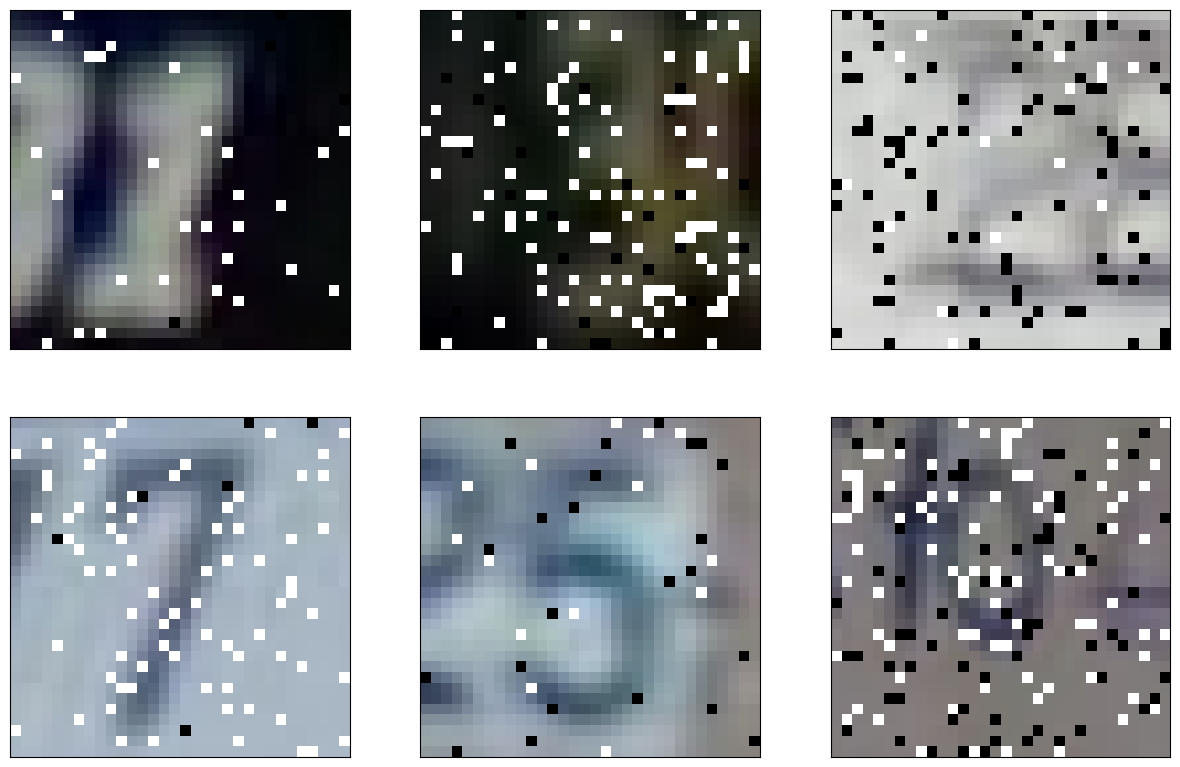

In [ ]:
plt.figure(figsize=(15,15))
for i in range(6):
    plt.subplot(3,3,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images_full[i], cmap=plt.cm.binary)
plt.show()

# Обработка данных

Данные зашумлены. Для решения этой проблемы воспользуемся блюром.

Ниже приведены некоторые методы удаления соль-перца


https://docs.opencv.org/4.x/d4/d13/tutorial_py_filtering.html <-- вот документация

1. Averaging. Он просто берет среднее значение всех пикселей под областью ядра и заменяет центральный элемент.

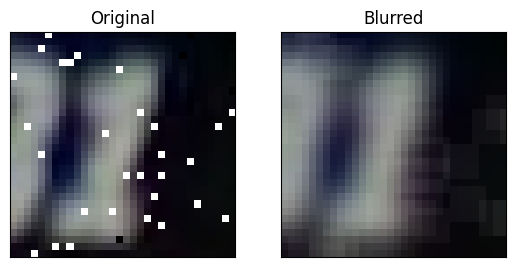

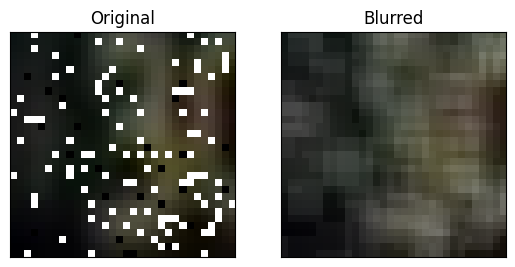

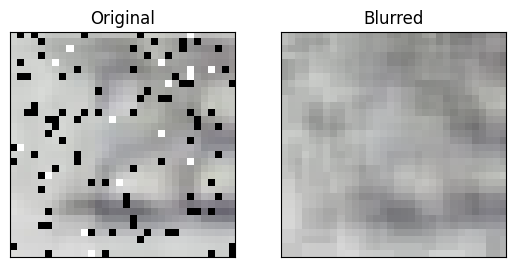

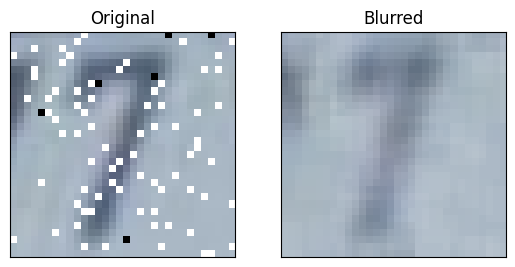

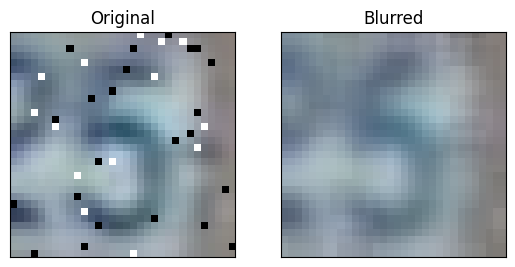

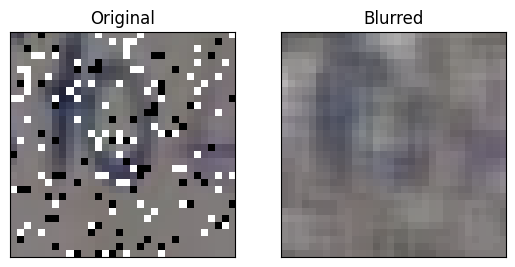

In [ ]:
for i in range(6):
    img = train_images_full[i]
    blur = cv.blur(img,(5,5))
    plt.subplot(121),plt.imshow(img),plt.title('Original')
    plt.xticks([]), plt.yticks([])
    plt.subplot(122),plt.imshow(blur),plt.title('Blurred')
    plt.xticks([]), plt.yticks([])
    plt.show()

Размытие по Гауссу. Как видим весьма небазированно получаются img.

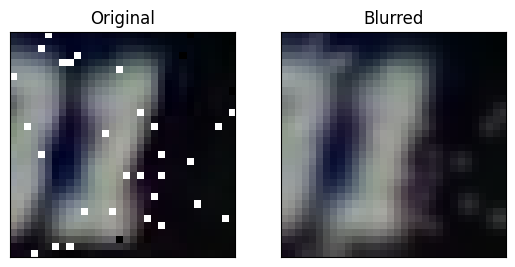

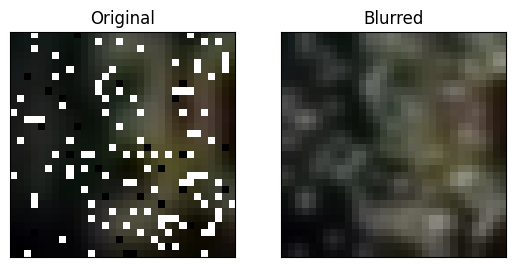

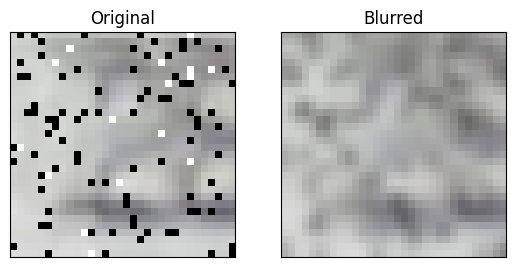

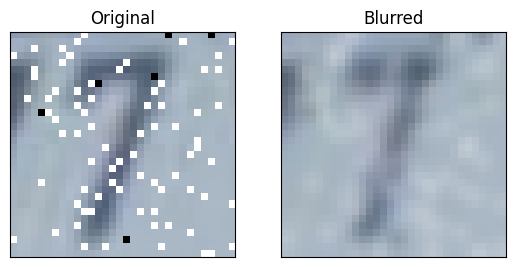

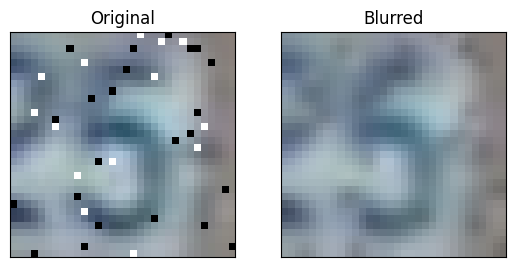

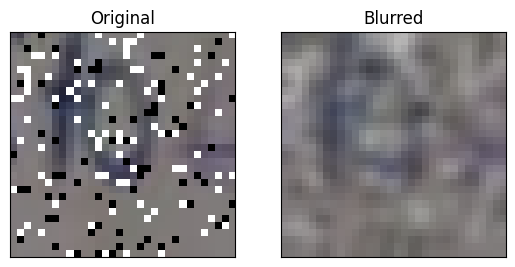

In [ ]:
for i in range(6):
    img = train_images_full[i]
    blur = cv.GaussianBlur(img,(5,5),0)
    plt.subplot(121),plt.imshow(img),plt.title('Original')
    plt.xticks([]), plt.yticks([])
    plt.subplot(122),plt.imshow(blur),plt.title('Blurred')
    plt.xticks([]), plt.yticks([])
    plt.show()

Медианное размытие. Вот тут результат в разы лучше. Median blurring выдал базы.

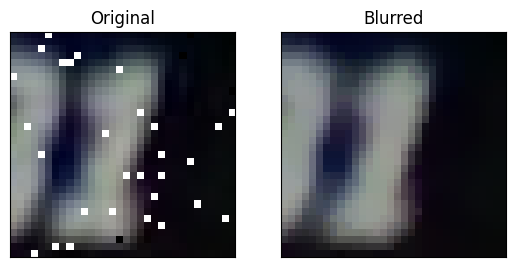

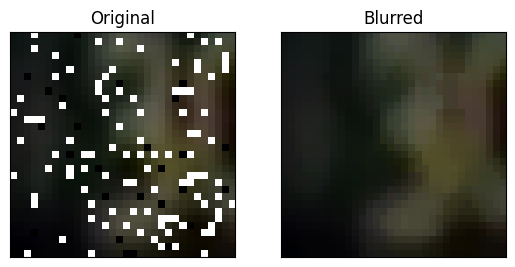

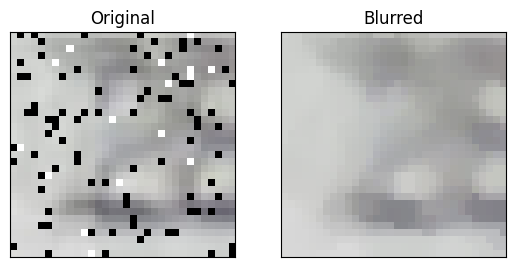

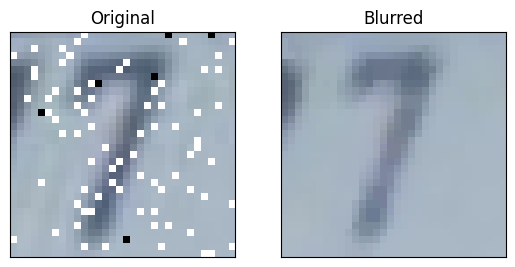

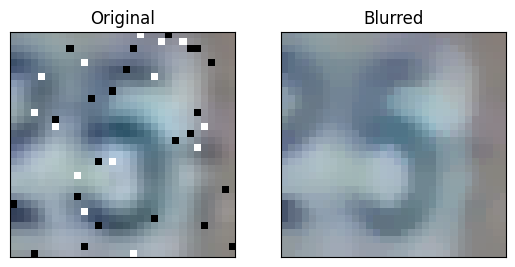

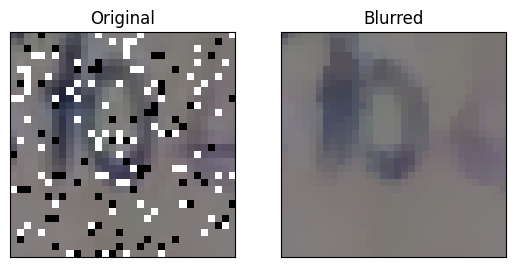

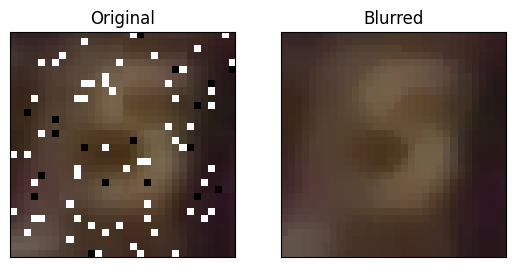

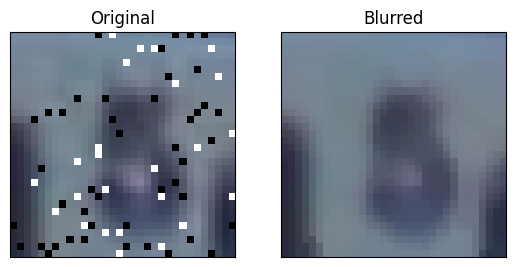

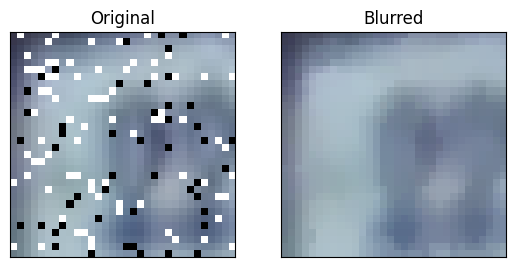

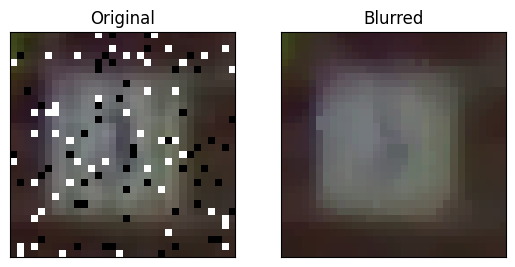

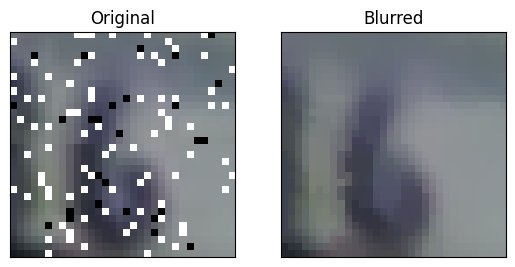

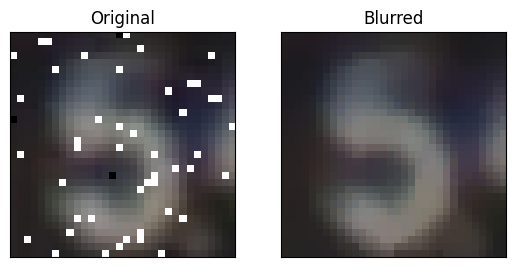

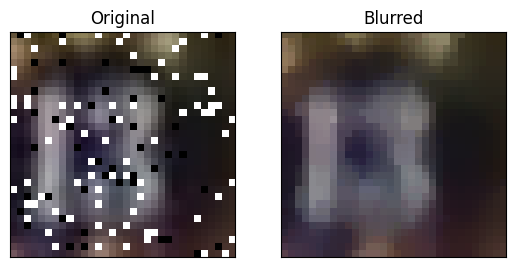

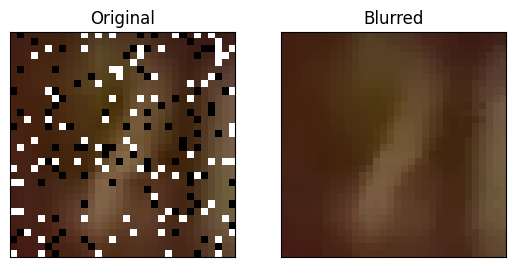

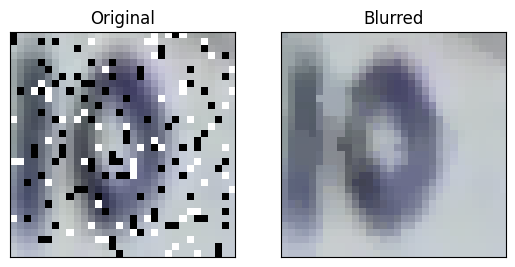

In [ ]:
for i in range(15):
    img = train_images_full[i]
    median = cv.medianBlur(img,5)
    plt.subplot(121),plt.imshow(img),plt.title('Original')
    plt.xticks([]), plt.yticks([])
    plt.subplot(122),plt.imshow(median),plt.title('Blurred')
    plt.xticks([]), plt.yticks([])
    plt.show()

Двусторонняя фильтрация ну ооочень уж сильно заблюрила наши имгшки, сетке будет тяжело с таким работать

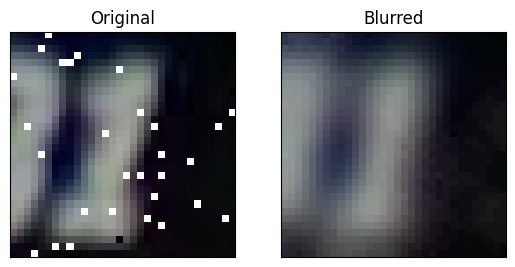

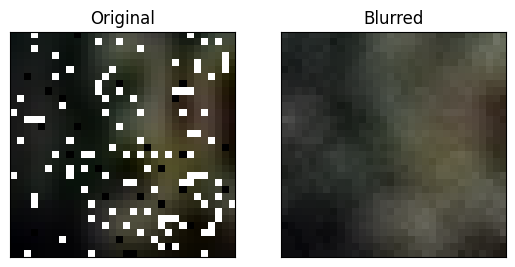

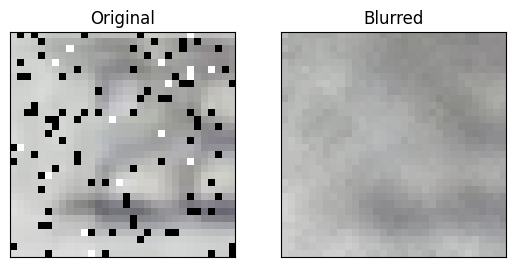

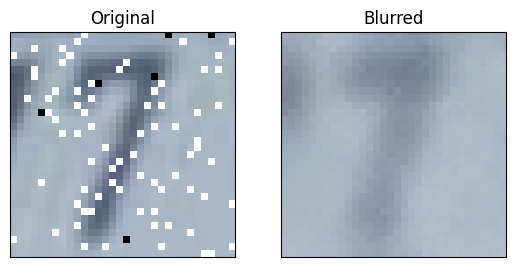

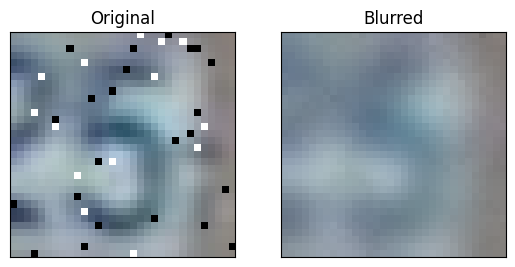

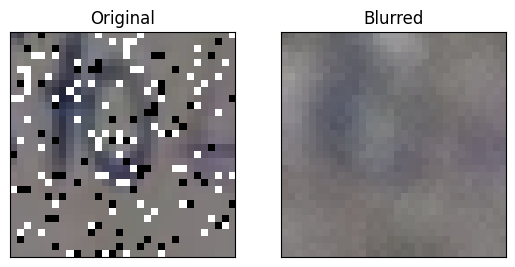

In [ ]:
for i in range(6):
    img = train_images_full[i]
    blur = cv.bilateralFilter(img,9,75,75)
    plt.subplot(121),plt.imshow(img),plt.title('Original')
    plt.xticks([]), plt.yticks([])
    plt.subplot(122),plt.imshow(blur),plt.title('Blurred')
    plt.xticks([]), plt.yticks([])
    plt.show()

Медианный блюр со значением k = 5 давал сильное размытие, а при k = 3 оставались шумы. Решением проблемы стало двойное применение блюра с k = 3

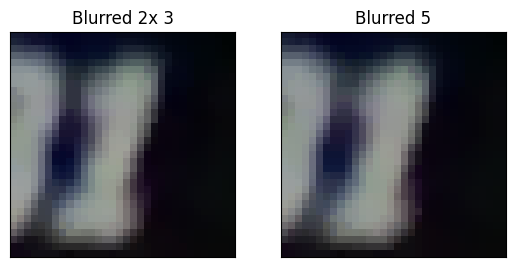

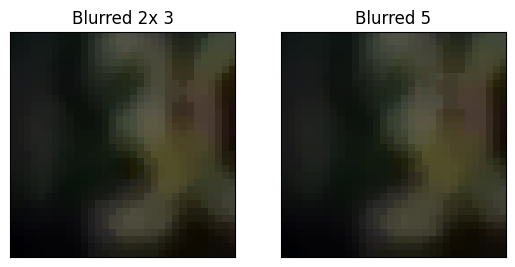

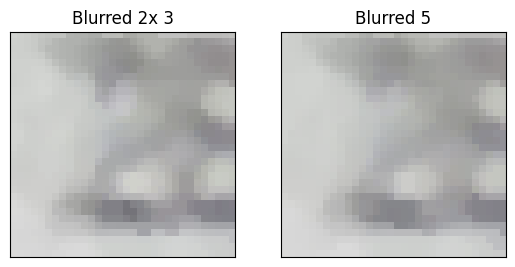

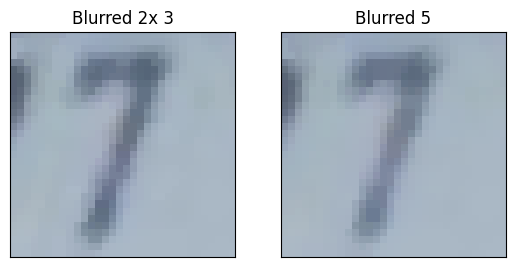

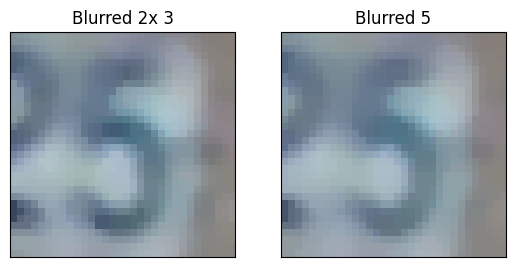

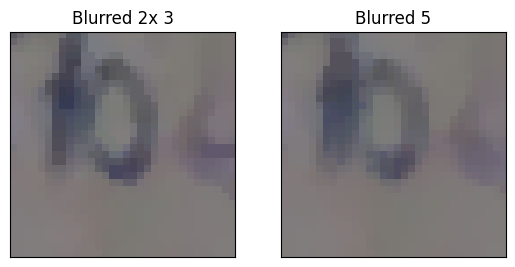

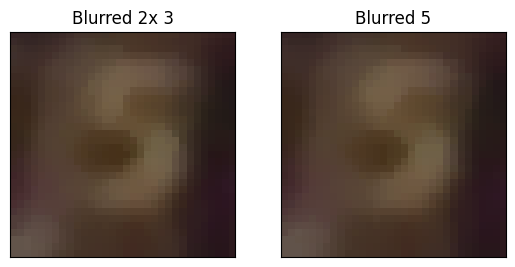

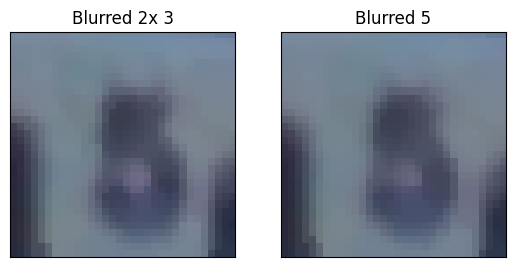

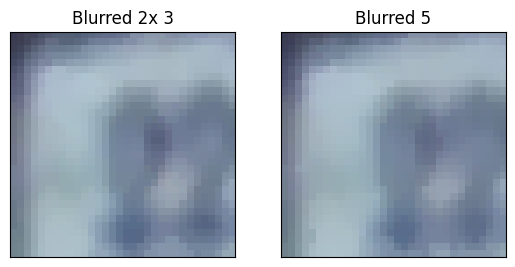

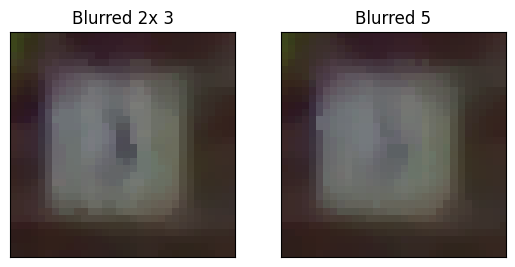

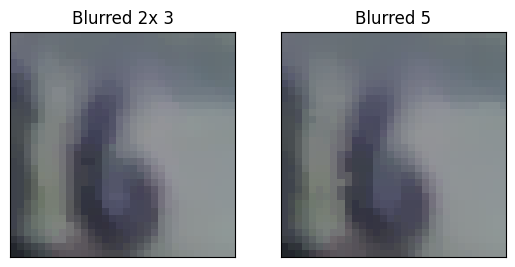

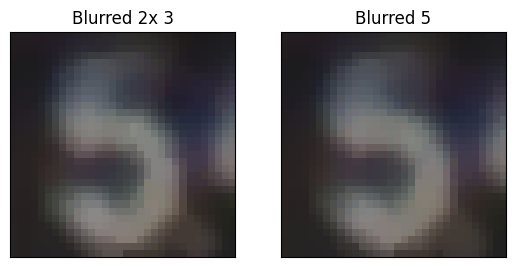

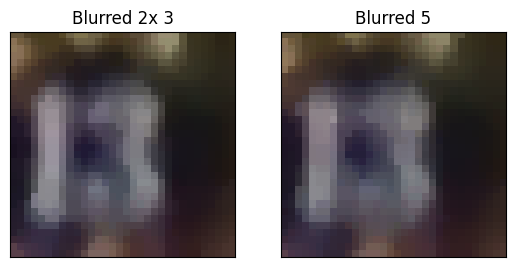

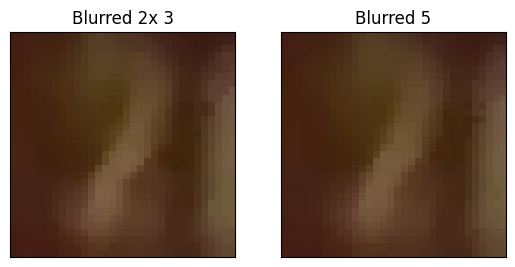

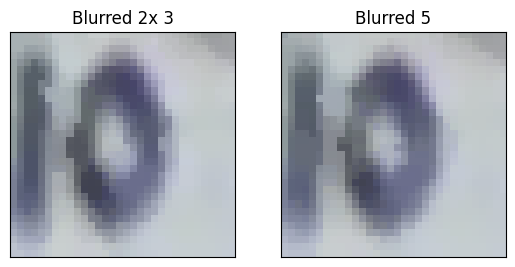

In [ ]:
for i in range(15):
    img = train_images_full[i]
    median = cv.medianBlur(cv.medianBlur(img,3),3)
    median1 = cv.medianBlur(img,5)
    plt.subplot(121), plt.imshow(median), plt.title('Blurred 2x 3')
    plt.xticks([]), plt.yticks([])
    plt.subplot(122), plt.imshow(median1), plt.title('Blurred 5')
    plt.xticks([]), plt.yticks([])
    plt.show()

Применим блюр и посмотрим на результат

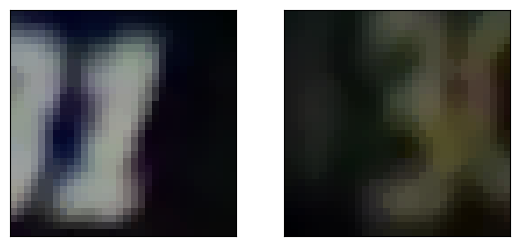

In [ ]:
vfunc = lambda x: cv.medianBlur(cv.medianBlur(x, 3), 3)
train_images_blured, test_images_blured = np.array(list(map(vfunc, train_images_full))), np.array(list(map(vfunc, test_images)))

plt.figure(figsize=(10,10))
for i in range(2):
    plt.subplot(3,3,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images_blured[i], cmap=plt.cm.binary)
plt.show()

Среди картинок есть те где находятся несколько номеров. Из-за этого нейросеть может выдавать ошибочные результаты. Обрежем наш датасет, убрав четверть справа и четверть слева, таким образом на картинке останется только нужный нам номер.

In [ ]:
train_images_blured_cropped, test_images_blured_cropped = np.copy(train_images_blured), np.copy(test_images_blured)
train_images_blured_cropped[:, :, :8, :] = np.zeros((50000, 32, 8, 3))
train_images_blured_cropped[:, :, 24:, :] = np.zeros((50000, 32, 8, 3))
test_images_blured_cropped[:, :, :8, :] = np.zeros((25000, 32, 8, 3))
test_images_blured_cropped[:, :, 24:, :] = np.zeros((25000, 32, 8, 3))

Посмотрим, что получилось

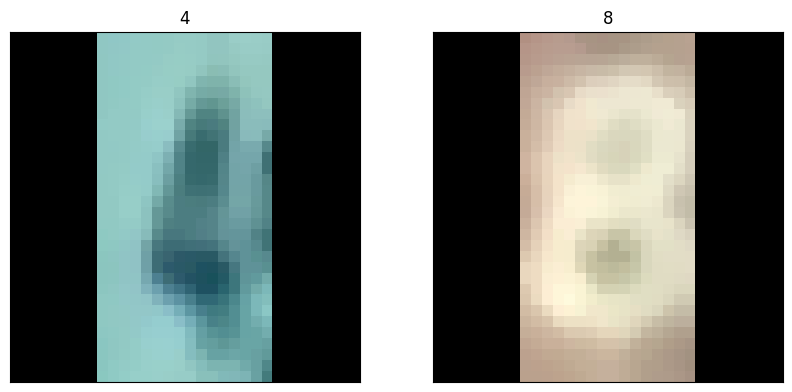

In [ ]:
plt.figure(figsize=(10,10))
for i in range(7000,7002):
    plt.subplot(2, 2, 7002 - i)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images_blured_cropped[i], cmap=plt.cm.binary)
    plt.title(train_labels_full[i])
plt.show()

Посмотрим на соотношение классов в тренировочной выборке

0 : 9650
1 : 5625
2 : 7595
3 : 3876
4 : 4604
5 : 3341
6 : 3859
7 : 4941
8 : 3177
9 : 3332


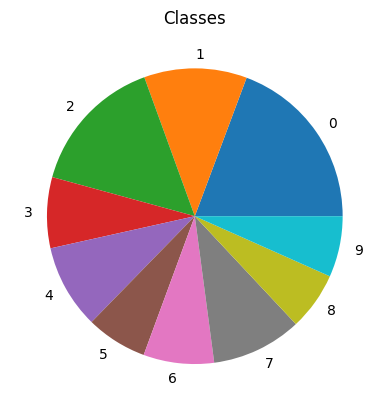

In [ ]:
from collections import Counter
sections = list(Counter(train_labels_full).values())

plt.pie(sections, labels=label_names)

for i in range(10):
    print(f'{i} : {sections[i]}')
# plt.axis('equal') # Try commenting this out.
plt.title('Classes')
plt.show()

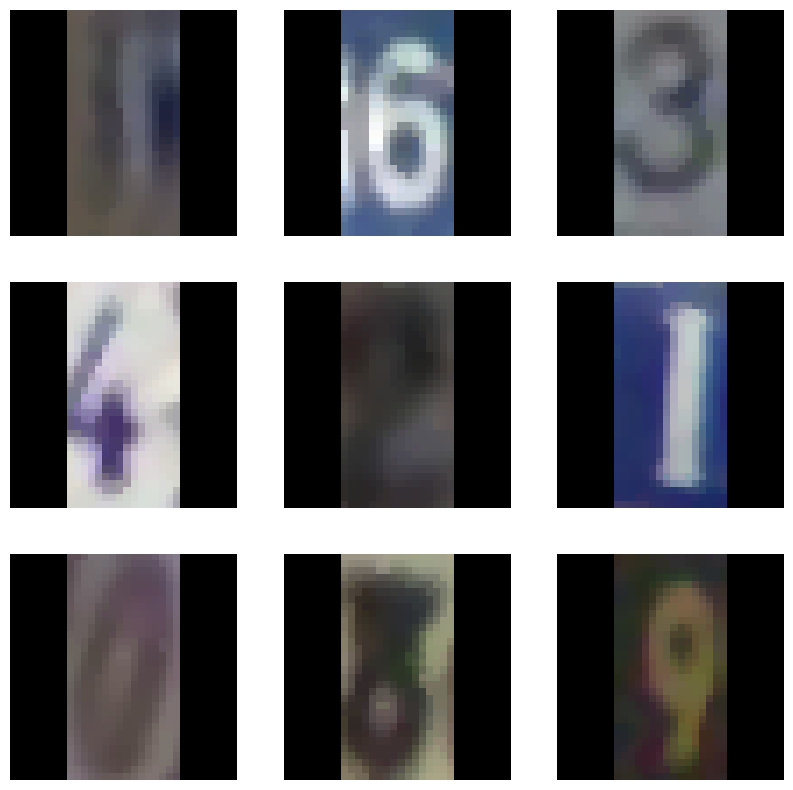

In [ ]:
plt.figure(figsize=(10, 10))
for i in range(2000, 2009):
  ax = plt.subplot(3, 3, 2009 - i)
  plt.imshow(test_images_blured_cropped[i])
  plt.axis("off")

Перейдём к финальной части работы с изображениями: используем onehot на лейблах и переведём датасет в тензоры

In [ ]:
from sklearn.model_selection import train_test_split

val_size = 0.2

train_labels_one_hot = tf.one_hot(train_labels_full, 10).numpy()
train_images, validation_images, train_labels, validation_labels = train_test_split(train_images_blured_cropped, train_labels_one_hot, test_size=val_size)
validation_images, val2_images, validation_labels, val2_labels = train_test_split(validation_images, validation_labels, test_size=0.1)


batch_size = 256

train_dataset = tf.data.Dataset.from_tensor_slices((train_images, train_labels))
train_dataset = train_dataset.shuffle(buffer_size=1024, reshuffle_each_iteration=True).batch(batch_size)

val_dataset = tf.data.Dataset.from_tensor_slices((validation_images, validation_labels)).batch(batch_size)
val2_dataset = tf.data.Dataset.from_tensor_slices((val2_images, val2_labels)).batch(batch_size)

test_dataset = tf.data.Dataset.from_tensor_slices((test_images_blured_cropped,)).batch(batch_size)

In [ ]:
import keras.backend as K

def f1_metric(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    precision = true_positives / (predicted_positives + K.epsilon())
    recall = true_positives / (possible_positives + K.epsilon())
    f1_val = 2 * (precision*recall) / (precision+recall + K.epsilon())
    return f1_val

In [ ]:
def show_metrics(model):
    test_loss, test_acc, test_prec, test_recall, test_f1score = model.evaluate(val2_images,  val2_labels, verbose=2)

    print('\nTest accuracy:', test_acc)
    print('\nTest precision:', test_prec)
    print('\nTest recall:', test_recall)
    print('\nTest f1score:', test_f1score)

# Аугментации

https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image/ImageDataGenerator

Датагенератор не меняет фотографии в самом начале, как это делает автоаугментация, а модифицирцет их в процессе обучения.

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

dataGenAns1 = ImageDataGenerator(
    zoom_range=[0.9, 1.1],
    rotation_range=8,
    height_shift_range=0.10,
    shear_range=0.3
)

# Создание нейросети

In [ ]:
input_shape = train_images.shape[-3:]

Модель. Подобие ResNet

In [ ]:
keras.backend.clear_session()


model = keras.Sequential([
    keras.layers.Input(shape=(32, 32, 3)),
    keras.layers.Conv2D(32, (3, 3), padding='same',
                           activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(32, (3, 3), padding='same',
                        activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Dropout(0.3),

    keras.layers.Conv2D(64, (3, 3), padding='same',
                           activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(64, (3, 3), padding='same',
                        activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Dropout(0.3),

    keras.layers.Conv2D(128, (3, 3), padding='same',
                           activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(128, (3, 3), padding='same',
                        activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Dropout(0.3),

    keras.layers.Conv2D(258, (3, 3), padding='same',
                           activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(258, (3, 3), padding='same',
                        activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Dropout(0.3),


    keras.layers.Flatten(),
    keras.layers.Dense(2056, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(10,  activation='softmax')
])




early_stopping = keras.callbacks.EarlyStopping(patience=8)
optimizer = keras.optimizers.Adam(lr=1e-3, amsgrad=True)
model_checkpoint = keras.callbacks.ModelCheckpoint(
                   '/kaggle/working/best_cnn.h5',
                   save_best_only=True)



model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

Обучение модели

In [ ]:
history11 = model.fit(dataGenAns1.flow(train_images_blured_cropped, train_labels_one_hot, batch_size=512),
                              epochs=50, validation_data=val_dataset,
                              callbacks=[early_stopping, model_checkpoint])

Помиотрим на графики accuracy и loss на тренировочном и валидационном датасетах

In [ ]:
acc = history11.history['accuracy']
val_acc = history11.history['val_accuracy']

In [ ]:
loss = history11.history['loss']
val_loss = history11.history['val_loss']

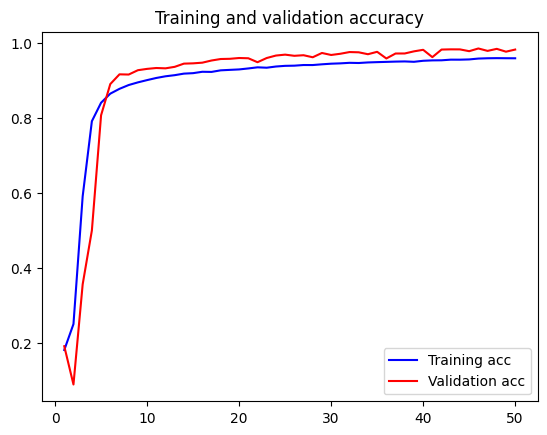

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, 'b', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()
plt.show()

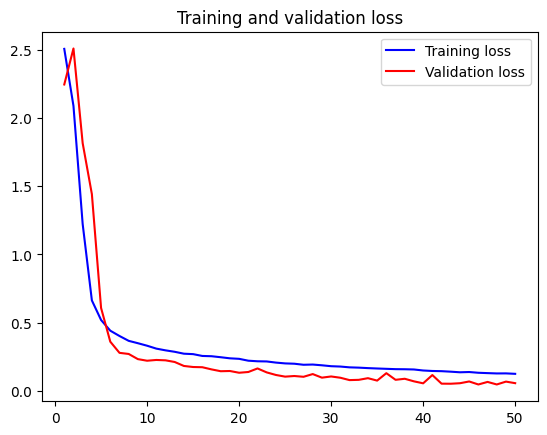

<Figure size 640x480 with 0 Axes>

In [ ]:
epochs = range(1, len(loss) + 1)

plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.figure()
plt.show()

В итоге была получена метрика 0.93973 в public score (0.94211 в private score)

# Получение предсказания

In [ ]:
preds = model.predict(test_dataset)
pred_labels = preds.argmax(1)
pd.DataFrame({
    'Id': range(pred_labels.size),
    'Category': pred_labels
}).to_csv('sub.csv', index=False)

98/98 [==============================] - 2s 12ms/step
